In [1]:
from jax.numpy import size
import numpy as np
from numpyro import distributions as dist
import numpyro
import polars as pl
import jax.numpy as jnp
from jax import random
import jax
from pathlib import Path
from sklearn.model_selection import train_test_split
import datetime as dt
from matplotlib import pyplot as plt
import xarray as xr

import arviz as az

numpyro.set_host_device_count(4)

data_dir = Path("./data")
df = (
    pl.read_csv(data_dir / "cleaned_games.csv")
    .with_columns(pl.col("Datetime").str.strptime(pl.Datetime).alias("Datetime"))
    .filter(
        pl.col("Datetime") >= dt.datetime(2025, 10, 1),
        pl.col("Arizona Coyotes") == 0,
    )
    .drop("Arizona Coyotes")
)

# current season games only

teams = (
    pl.read_csv(data_dir / "teams.txt", has_header=False)
    .filter(pl.col("column_1") != "Arizona Coyotes")
    .to_series()
    .to_list()
)



In [10]:
day_of_season = (df["Datetime"] - df["Datetime"].min()).dt.total_days().to_jax()
day_of_season = day_of_season - day_of_season.mean()
team_matchups = df[teams].to_jax()
home_wins = df["home_win"].to_jax()
home_goals = df["Home_G"].to_jax()
away_goals = df["Away_G"].to_jax()
overtimes = df["OT"].to_jax()


home_win_ot = home_wins * overtimes
away_win_ot = (1 - home_wins) * overtimes

home_g_reg = jnp.where(home_win_ot == 1, home_goals - 1, home_goals)
away_g_reg = jnp.where(away_win_ot == 1, away_goals - 1, away_goals)

train_shape = int(0.8 * len(df))

train_matchups, test_matchups, train_home_wins, test_home_wins, train_away_goals, test_away_goals, train_home_goals, test_home_goals, train_overtimes, test_overtimes = (
    team_matchups[:train_shape],
    team_matchups[train_shape:],
    home_wins[:train_shape],
    home_wins[train_shape:],
    away_g_reg[:train_shape],
    away_g_reg[train_shape:],
    home_g_reg[:train_shape],
    home_g_reg[train_shape:],
    overtimes[:train_shape],
    overtimes[train_shape:],
)


In [141]:

def log_bessel_fn(x, n, max_terms=30):
    def log_term(k):
        return (
            (2*k + n) * jnp.log(x/2) - jax.scipy.special.gammaln(k + n + 1) - jax.scipy.special.gammaln(k + 1)
        )

    bessel_approx = jax.scipy.special.logsumexp(jax.vmap(log_term)(jnp.arange(max_terms)), axis=0)
    return bessel_approx

class NonZeroSkellam(dist.Distribution):
    arg_constraints = {"mu1": dist.constraints.positive, "mu2": dist.constraints.positive}
    support = dist.constraints.integer_interval(-jnp.inf, jnp.inf)

    def __init__(self, mu1, mu2, validate_args=None):
        self.mu1 = mu1
        self.mu2 = mu2
        super().__init__(batch_shape=jnp.shape(mu1), validate_args=validate_args)

    def _raw_log_pmf(self, k):
        log_pmf = (
            - (self.mu1 + self.mu2) + k * jnp.log(self.mu1 / self.mu2) / 2 + log_bessel_fn(2 * jnp.sqrt(self.mu1 * self.mu2), jnp.abs(k))
        )
        return log_pmf 

    def log_prob(self, k):
        log_zero_prob = self._raw_log_pmf(0)
        log_pmf_k = self._raw_log_pmf(k)
        log_nonzero_prob = jnp.log1p(-jnp.exp(log_zero_prob))

        return jnp.where(k == 0, -jnp.inf, log_pmf_k - log_nonzero_prob)

    def sample(self, key, sample_shape=()):

        def condn_fn(state):
            _, samples = state
            return jnp.any(samples == 0)

        def _run_samples(key):
            k1, k2 = jax.random.split(key, 2)
            return dist.Poisson(self.mu1).sample(k1, sample_shape) - dist.Poisson(self.mu2).sample(k2, sample_shape)

        key1, key2 = random.split(key)
        initial_samples = _run_samples(key1)

        def sample_fn(state):
            key, samples = state
            new_key, subkey = random.split(key)
            candidates = _run_samples(new_key)
            return subkey, jnp.where(samples == 0, candidates, samples)

        return jax.lax.while_loop(condn_fn, sample_fn, (key2, initial_samples))[1]

class Skellam(dist.Distribution):
    arg_constraints = {"mu1": dist.constraints.positive, "mu2": dist.constraints.positive}
    support = dist.constraints.integer_interval(-jnp.inf, jnp.inf)

    def __init__(self, mu1, mu2, validate_args=None):
        self.mu1 = mu1
        self.mu2 = mu2
        super().__init__(batch_shape=jnp.shape(mu1), validate_args=validate_args)

    def log_prob(self, k):
        log_pmf = (
            - (self.mu1 + self.mu2) + k * jnp.log(self.mu1 / self.mu2) / 2 + log_bessel_fn(2 * jnp.sqrt(self.mu1 * self.mu2), jnp.abs(k))
        )
        return log_pmf

    def sample(self, key, sample_shape=()):
        key1, key2 = random.split(key)
        return dist.Poisson(self.mu1).sample(key1, sample_shape) - dist.Poisson(self.mu2).sample(key2, sample_shape)


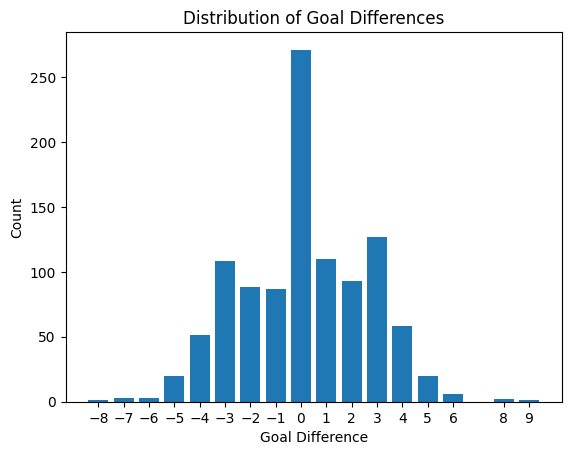

In [13]:
vals, counts = jnp.unique_counts(train_home_goals - train_away_goals)
fig, ax = plt.subplots()
ax.bar(vals, counts)
ax.set_xlabel("Goal Difference")
ax.set_ylabel("Count")
ax.set_xticks(vals)
ax.set_title("Distribution of Goal Differences")
plt.show()

In [328]:
def model(matchups, home_g=None, away_g=None, is_ot=None, home_win=None):
    sigma_offense = numpyro.sample("sigma_offense", dist.InverseGamma(1, 1))
    sigma_defense = numpyro.sample("sigma_defense", dist.InverseGamma(1, 1))

    home_advantage = numpyro.sample("home_advantage", dist.Normal(0, 0.1))
    base_intercept = numpyro.sample("base_intercept", dist.Normal(0, 1))
    # Non-centered: sample on unit scale, multiply by sigma outside
    with numpyro.plate("teams", size=matchups.shape[1]):
        offense_raw = numpyro.sample("offense_raw", dist.Normal(0, 1))
        defense_raw = numpyro.sample("defense_raw", dist.Normal(0, 1))
        # team_home_advantage = numpyro.sample("team_home_advantage", dist.Normal(home_advantage, sigma_home_team))

    # Scale + sum-to-zero: kills the add-c-to-both degeneracy
    log_offense = sigma_offense * (offense_raw - offense_raw.mean())
    log_defense = sigma_defense * (defense_raw - defense_raw.mean())
    numpyro.deterministic("offense_goals", jnp.exp(log_offense))
    numpyro.deterministic("defense_goals", jnp.exp(log_defense))

    home_team_idx = jnp.argmax(matchups, axis=1)
    away_team_idx = jnp.argmin(matchups, axis=1)

    lambda_home = numpyro.deterministic("lambda_home", jnp.exp(base_intercept + log_offense[home_team_idx] - log_defense[away_team_idx] + home_advantage))
    lambda_away = numpyro.deterministic("lambda_away", jnp.exp(base_intercept + log_offense[away_team_idx] - log_defense[home_team_idx]))
    ot_mask = (home_g == away_g) if is_ot is None else is_ot == 1
    ot_win_prob = numpyro.deterministic("win_prob", lambda_home / (lambda_home + lambda_away))
    skellam_pmf = Skellam(lambda_home, lambda_away)

    prob_1_or_greater = jnp.exp(jax.vmap(skellam_pmf.log_prob, in_axes=(0))(jnp.arange(1, 12))).sum(axis=0)
    prob_0 = jnp.exp(skellam_pmf.log_prob(0)) * ot_win_prob
    prob_home_win = numpyro.deterministic("prob_home_win", prob_1_or_greater + prob_0)

    with numpyro.plate("obs", size=matchups.shape[0]):
        home_g = numpyro.sample("home_g_raw", dist.Poisson(lambda_home), obs=home_g)
        away_g = numpyro.sample("away_g_raw", dist.Poisson(lambda_away), obs=away_g)

        home_ot_wins = numpyro.sample("home_ot_wins", dist.Bernoulli(ot_win_prob), obs=home_win, obs_mask=ot_mask)

        home_g_final = numpyro.deterministic("home_g", home_g + jnp.where(ot_mask, home_ot_wins.astype(int), 0))
        away_g_final = numpyro.deterministic("away_g", away_g + jnp.where(ot_mask, 1 - home_ot_wins.astype(int), 0))

        


In [329]:
kernel = numpyro.infer.NUTS(model)
mcmc = numpyro.infer.MCMC(
    kernel,
    num_warmup=2000,
    num_samples=1000,
    num_chains=4,
)

mcmc.run(random.key(90981238), matchups=train_matchups, home_g=train_home_goals, away_g=train_away_goals, is_ot=train_overtimes, home_win=train_home_wins)

Compiling.. :   0%|          | 0/3000 [00:00<?, ?it/s]







In [330]:
trace = az.from_numpyro(
    mcmc,
    coords={"team": teams},
    dims={
        "offense_goals": ["team"],
        "defense_goals": ["team"],
    },
)


Running chain 0:  75%|███████▌  | 2250/3000 [00:04<00:00, 1132.21it/s]


Running chain 0:  80%|████████  | 2400/3000 [00:04<00:00, 1096.09it/s]


Running chain 0:  85%|████████▌ | 2550/3000 [00:04<00:00, 1069.62it/s]


Running chain 0:  90%|█████████ | 2700/3000 [00:04<00:00, 1053.20it/s]


Running chain 0:  95%|█████████▌| 2850/3000 [00:04<00:00, 1040.69it/s]

Running chain 1: 100%|██████████| 3000/3000 [00:04<00:00, 601.01it/s] 

Running chain 0: 100%|██████████| 3000/3000 [00:05<00:00, 593.84it/s] 


Running chain 3: 100%|██████████| 3000/3000 [00:05<00:00, 594.43it/s] 

Running chain 2: 100%|██████████| 3000/3000 [00:05<00:00, 584.73it/s] 


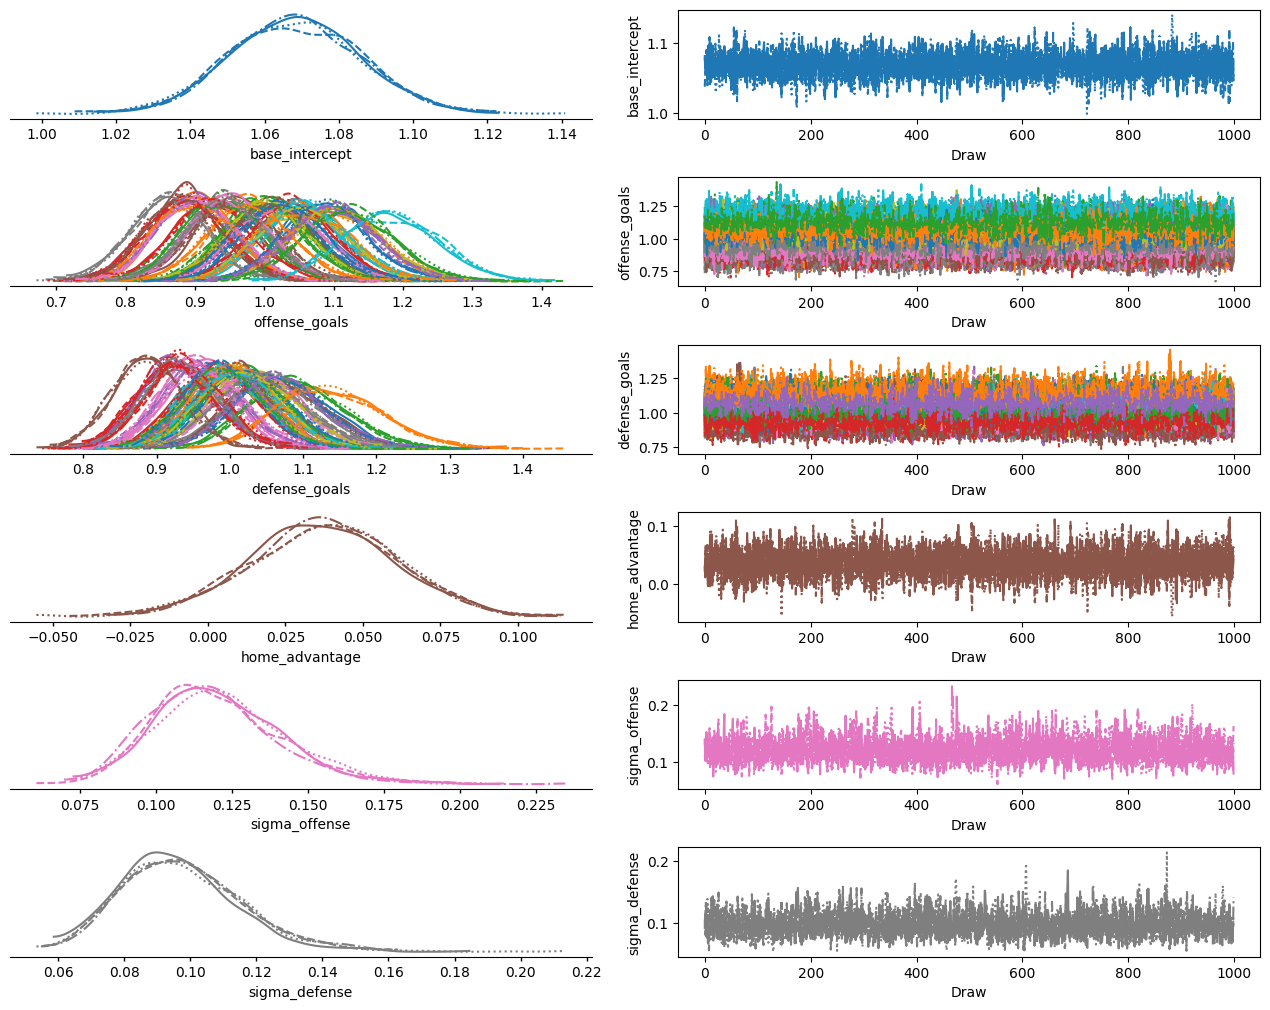

In [331]:
az.plot_trace_dist(trace, var_names=["base_intercept", "offense_goals", "defense_goals", "home_advantage", "sigma_offense", "sigma_defense"])
plt.tight_layout()

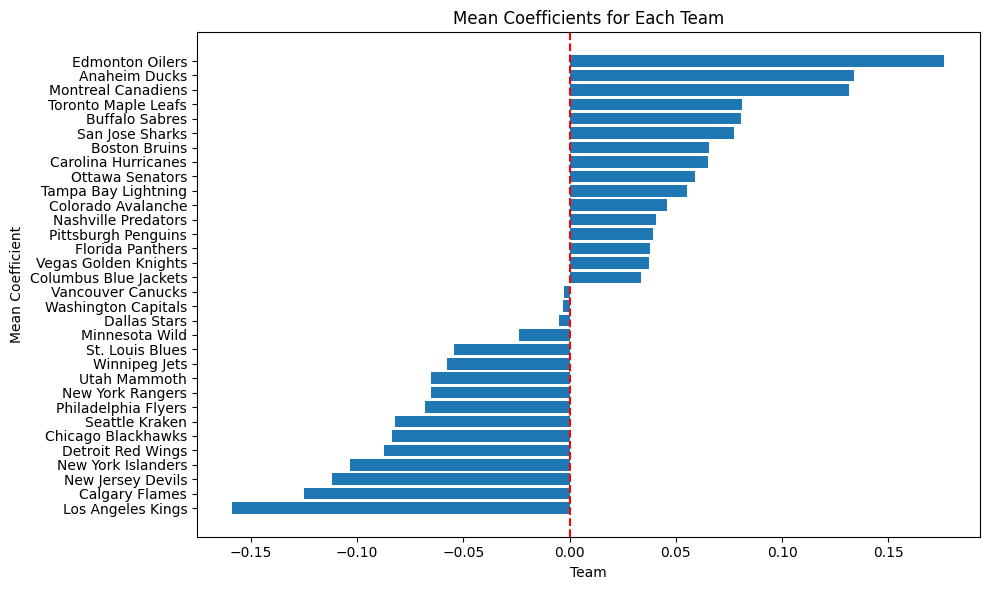

In [332]:
ranked = (trace.posterior["offense_goals"] - trace.posterior["defense_goals"]).mean(dim=["chain", "draw"])
ranked = ranked.sortby(ranked)

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(ranked.team.values, ranked.values)
ax.set_title("Mean Coefficients for Each Team")
ax.set_xlabel("Team")
ax.set_ylabel("Mean Coefficient")
ax.axvline(0, color="red", linestyle="dashed")
plt.tight_layout()


In [333]:
from numpyro.infer import Predictive

predict = Predictive(model, mcmc.get_samples())

pred_key = random.key(90198234)
preds = predict(pred_key, test_matchups)

In [339]:
def accuracy_score(y_true, y_pred):
    return np.mean(y_true == y_pred)

test_predictions = preds["prob_home_win"] > 0.5
full_accuracy = accuracy_score(test_home_wins, test_predictions.mean(axis=0) > 0.5)
print(f"Full (Skellam) Accuracy: {full_accuracy:.3f}")


Full (Skellam) Accuracy: 0.582


In [366]:
game_states = [(w, l) for w in range(5) for l in range(5) if w + l <= 7]
terminal_states = [t for t in game_states if 4 in t]
transitional_states = [s for s in game_states if s not in terminal_states]
game_states = transitional_states + terminal_states


def generate_matchup(home_team, away_team, teams=teams):
    home_idx, away_idx = teams.index(home_team), teams.index(away_team)
    input_idx = jnp.zeros(len(teams))
    input_idx = input_idx.at[home_idx].set(1)
    input_idx = input_idx.at[away_idx].set(-1)
    return input_idx.reshape(1, -1)


def make_transition_indices(game_states):
    from_idx, to_win_idx, to_loss_idx, terminal_idx = [], [], [], []
    for i, state in enumerate(game_states):
        if 4 in state:
            terminal_idx.append(i)
        else:
            from_idx.append(i)
            to_win_idx.append(game_states.index((state[0] + 1, state[1])))
            to_loss_idx.append(game_states.index((state[0], state[1] + 1)))
    return (jnp.array(from_idx), jnp.array(to_win_idx), 
            jnp.array(to_loss_idx), jnp.array(terminal_idx))

# Precompute once — Python loops run here, not inside JIT
from_idx, to_win_idx, to_loss_idx, terminal_idx = make_transition_indices(game_states)

@jax.jit
def construct_transition_matrix(p):
    n = len(game_states)
    mat = jnp.zeros((n, n))
    mat = mat.at[from_idx, to_win_idx].set(p)
    mat = mat.at[from_idx, to_loss_idx].set(1 - p)
    mat = mat.at[terminal_idx, terminal_idx].set(1.0)
    return mat

In [367]:

def run_playoff_series(rng_key, home_team, away_team, game_states):

    home_matchup = generate_matchup(home_team, away_team)
    away_matchup = -home_matchup

    k1, k2 = random.split(rng_key, 2)
    home_goals = predict(k1, home_matchup)
    away_goals = predict(k2, away_matchup)

    home_matrices = jax.vmap(construct_transition_matrix, in_axes=(0,))(home_goals["prob_home_win"])
    away_matrices = jax.vmap(construct_transition_matrix, in_axes=(0,))(1-away_goals["prob_home_win"])

    series_outcomes = jax.vmap(lambda hm, am: hm @ hm @ am @ am @ hm @ am @ hm, in_axes=(0, 0))(home_matrices, away_matrices)[:, 0, :]
    return xr.DataArray(
        series_outcomes,
        dims=["sample", "game_state"],
        coords={"game_state": [f"{w}-{l}" for w, l in game_states], "sample": np.arange(series_outcomes.shape[0])},
    ).sel(game_state=[f"{w}-{l}" for w, l in game_states if 4 in (w, l)])



In [ ]:
teamA = "Buffalo Sabres"
teamB = "Montreal Canadiens"
series_example = run_playoff_series(random.key(12938), teamA, teamB, game_states=game_states)

a_to_states = ["4-0", "4-1", "4-2", "4-3"]
b_to_states = ["3-4", "2-4", "1-4", "0-4"]

team_A_win_probs = series_example.sel(game_state=a_to_states).mean(dim="sample")
team_B_win_probs = series_example.sel(game_state=b_to_states).mean(dim="sample")


print(f"Probability {teamA} win series: {team_A_win_probs.sum():.3f}")
print("-----------------------------------\n")
print("Series Outcome Probabilities:\n")
for p, state in zip(team_A_win_probs.values, team_A_win_probs.coords["game_state"]):
    print(f"P({teamA}:{state.item()}) = {p:.3f}")

print("\n")

print(f"Probability {teamB} win series: {team_B_win_probs.sum():.3f}")
print("-----------------------------------\n")
for p, state in zip(team_B_win_probs.values, team_B_win_probs.coords["game_state"]):
    print(f"P({teamB}:{state.item()}) = {p:.3f}")